# Predictive Analytics in Business Sales Project

**Project type:** Regression

**Business problem:** Predict `Item_Outlet_Sales` from product and outlet characteristics.

**Source:** Big Mart Sales Prediction dataset from Kaggle. The dataset contains 8,523 training observations and 12 variables; `Item_Outlet_Sales` is the continuous outcome.

> **AI-use disclosure:** AI tools were used to support coding, debugging, and explanation. The student must review, understand, validate, and rewrite the interpretations/business recommendations before submission, in accordance with the course AI-use guidance.

**Important:** Run this notebook with the same `train.csv` used for the project. The workflow below performs preprocessing inside the modeling pipeline to avoid train/test leakage.

## 1. Business objective

A retailer wants to estimate the sales value of a product at a particular outlet. Accurate predictions can support inventory planning, assortment decisions, and sales forecasting.

**Target:** `Item_Outlet_Sales`

**Primary evaluation metrics:** MAE, MAPE, MSE, RMSE, and R².


## 2. What this notebook covers

1. Data loading and audit
2. Missing-value and duplicate checks
3. Data normalization and feature engineering
4. IQR-based outlier analysis
5. Exploratory Data Analysis (EDA)
6. Feature selection
7. Multiple regression models
8. Hyperparameter optimization
9. Cross-validation
10. Final evaluation
11. Feature importance and business observations


Shape: (8523, 12)
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999      Medium 

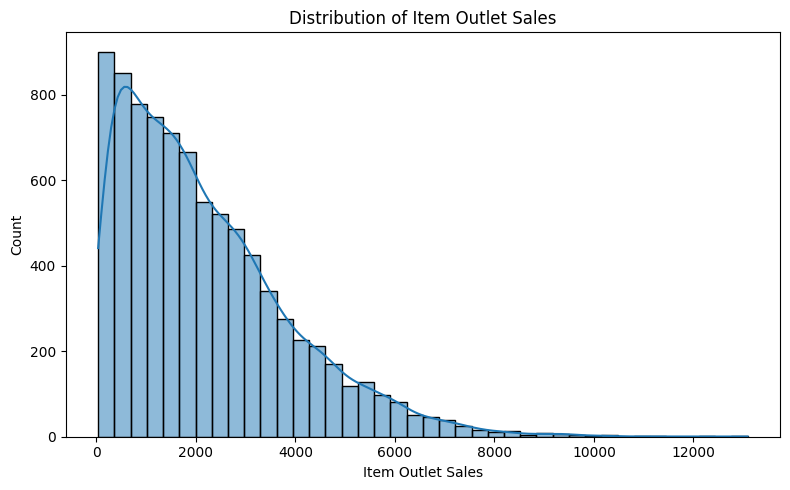

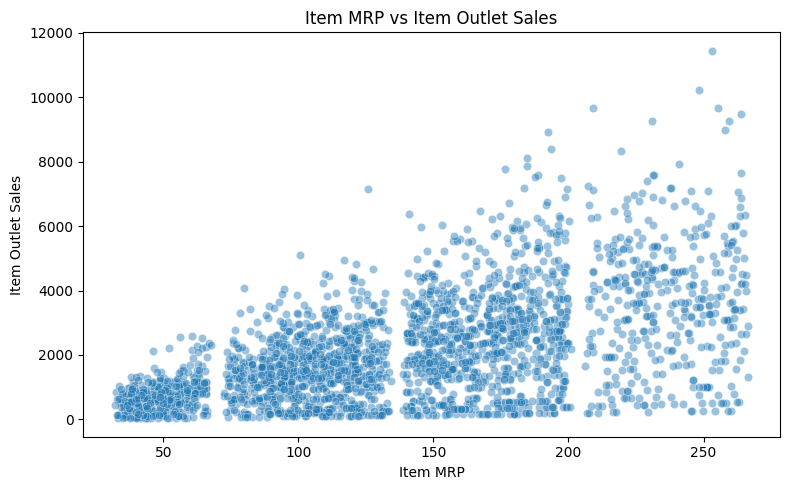

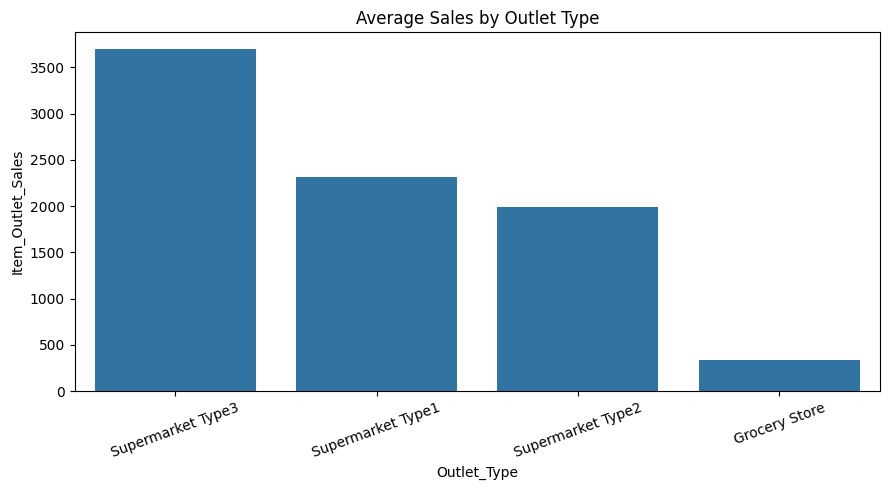

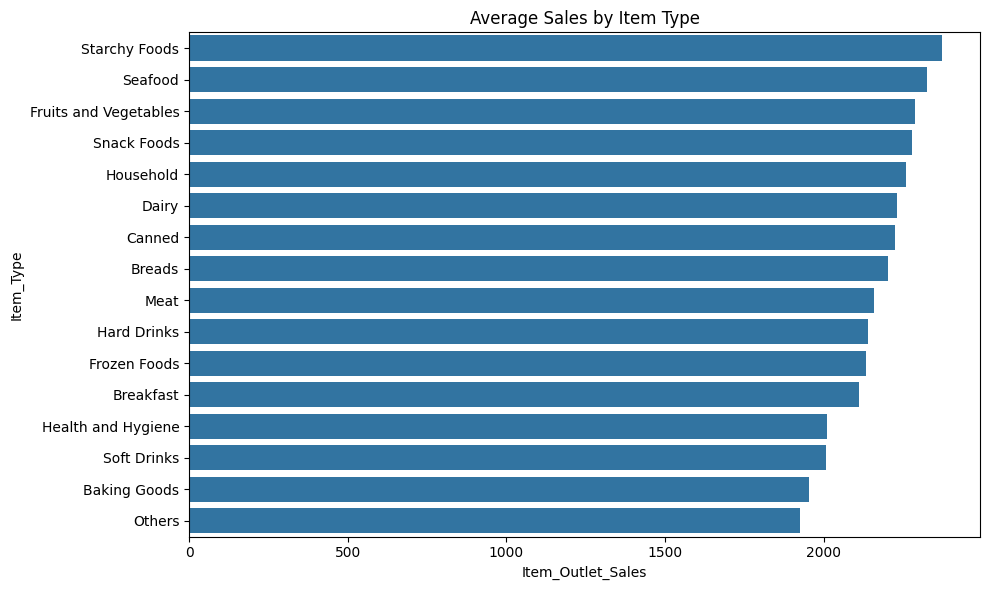

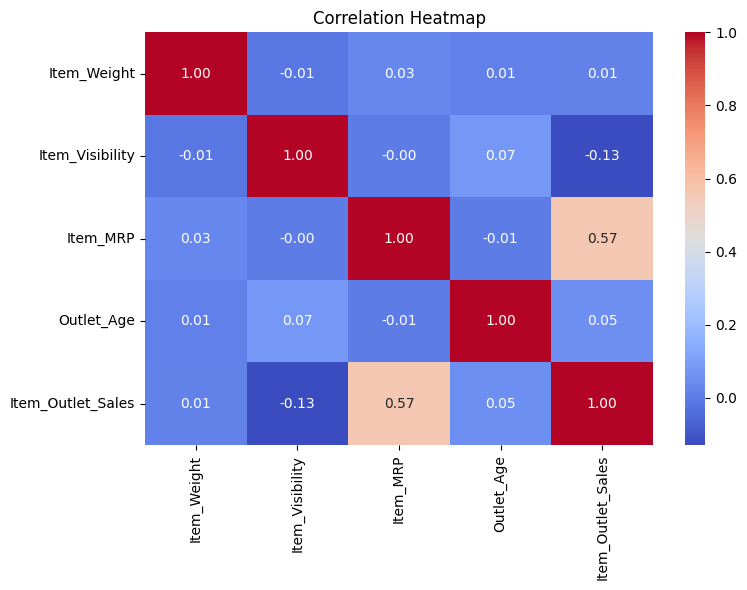


Model comparison:
                  Model      MAE   MAPE_%          MSE      RMSE     R2
2         Random Forest  743.427   56.511  1139285.441  1067.373  0.581
0     Linear Regression  792.025  106.254  1143541.300  1069.365  0.579
3  HistGradientBoosting  747.720   57.996  1160130.702  1077.094  0.573
1         Decision Tree  800.783   58.453  1321588.943  1149.604  0.514

Best RF parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': 8}
Best 5-fold CV RMSE: 1097.517819537073

Optimized RF test metrics:
MAE       7.170336e+02
MAPE_%    5.550820e+01
MSE       1.050935e+06
RMSE      1.025151e+03
R2        6.133000e-01
dtype: float64

Cross-validation RMSE scores: [1025.    1075.664 1081.388 1118.688 1114.079]
Mean CV RMSE: 1082.9640514933915
CV RMSE std: 33.64505650872377
Mean CV R2: 0.5966818382504083

Final model comparison:
                     Model      MAE   MAPE_%          MSE      R

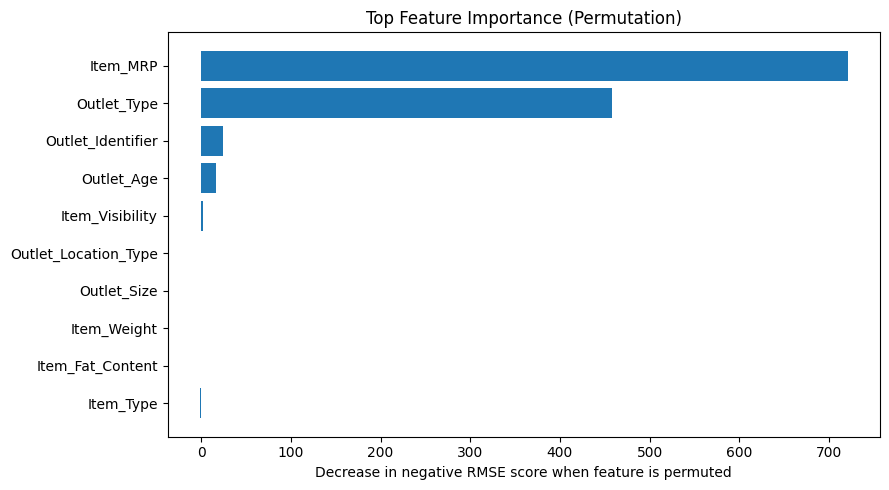

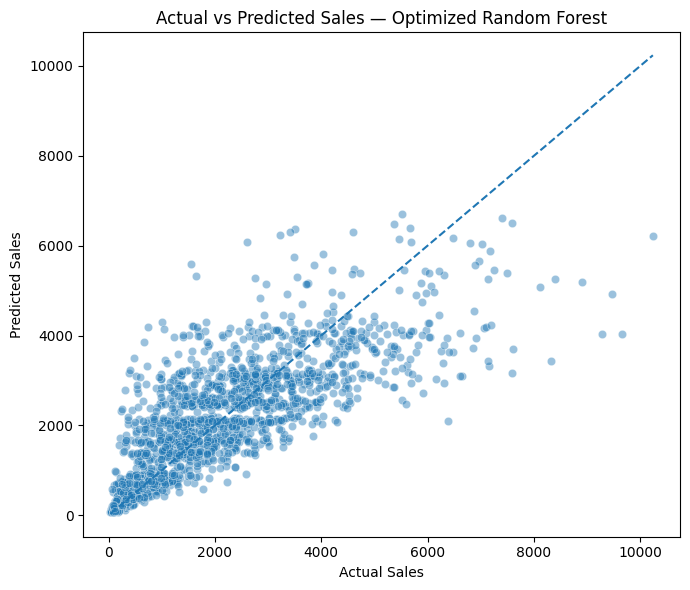

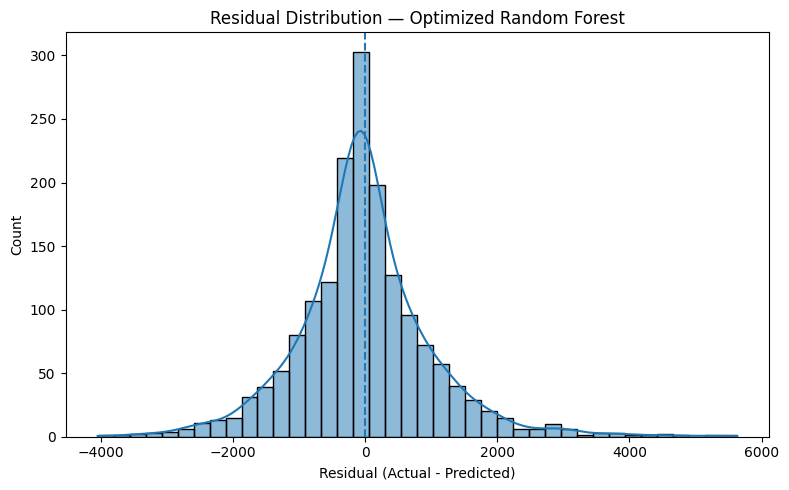


Candidate observations for the student to verify and interpret:
• Outlet type with highest average sales: Supermarket Type3 (3694.04)
• Item type with highest average sales: Starchy Foods (2374.33)
• Highest permutation-importance feature: Item_MRP (720.72136)
• Final selected model by lowest test RMSE: Optimized Random Forest

Project run complete. Results saved under: /content/MIS444_BigMart_Final/results


In [2]:
# This file is a plain-Python version of the notebook workflow.
# It is also embedded into the .ipynb created by the setup script.

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

# -----------------------
# 0. Project paths
# -----------------------
PROJECT_ROOT = Path('/content')
DATA_PATH = PROJECT_ROOT / 'train.csv'
RESULTS_DIR = PROJECT_ROOT / 'MIS444_BigMart_Final' / 'results'
FIGURES_DIR = PROJECT_ROOT / 'MIS444_BigMart_Final' / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------
# 1. Load data
# -----------------------
assert DATA_PATH.exists(), f"Upload train.csv to Colab, then run again. Expected: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print(df.head())

# -----------------------
# 2. Initial audit
# -----------------------
print('\nData types and non-null counts:')
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nNumeric summary:')
print(df.describe())

# -----------------------
# 3. Data cleaning + feature engineering
# -----------------------
# Normalize inconsistent labels in Item_Fat_Content.
fat_map = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'Low Fat': 'Low Fat',
    'reg': 'Regular',
    'Regular': 'Regular'
}
df['Item_Fat_Content'] = df['Item_Fat_Content'].map(fat_map).fillna(df['Item_Fat_Content'])

# Outlet age measured relative to the dataset's reference year (2013).
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# -----------------------
# 4. Outlier analysis (IQR)
# -----------------------
def iqr_report(frame, columns):
    rows = []
    for col in columns:
        q1 = frame[col].quantile(0.25)
        q3 = frame[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (frame[col] < lower) | (frame[col] > upper)
        rows.append({
            'Feature': col,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Lower_Bound': lower,
            'Upper_Bound': upper,
            'Outlier_Count': int(mask.sum()),
            'Outlier_Percentage': float(mask.mean() * 100)
        })
    return pd.DataFrame(rows)

numeric_for_outliers = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Item_Outlet_Sales']
outlier_table = iqr_report(df, numeric_for_outliers)
print('\nIQR outlier analysis:')
print(outlier_table.round(3))
outlier_table.to_csv(RESULTS_DIR / 'outlier_analysis.csv', index=False)

# We do not delete observations automatically. Extreme sales can be legitimate observations.
# RobustScaler is used later for numeric predictors to reduce sensitivity to extreme predictor values.

# -----------------------
# 5. EDA
# -----------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['Item_Outlet_Sales'], bins=40, kde=True)
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Item Outlet Sales')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_sales_distribution.png', dpi=200)
plt.show()

sample = df.sample(min(2500, len(df)), random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.45)
plt.title('Item MRP vs Item Outlet Sales')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_mrp_vs_sales.png', dpi=200)
plt.show()

outlet_sales = df.groupby('Outlet_Type', as_index=False)['Item_Outlet_Sales'].mean().sort_values('Item_Outlet_Sales', ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(data=outlet_sales, x='Outlet_Type', y='Item_Outlet_Sales')
plt.title('Average Sales by Outlet Type')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_sales_by_outlet_type.png', dpi=200)
plt.show()

item_type_sales = df.groupby('Item_Type', as_index=False)['Item_Outlet_Sales'].mean().sort_values('Item_Outlet_Sales', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=item_type_sales, x='Item_Outlet_Sales', y='Item_Type')
plt.title('Average Sales by Item Type')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_sales_by_item_type.png', dpi=200)
plt.show()

corr_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Item_Outlet_Sales']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_correlation_heatmap.png', dpi=200)
plt.show()

# -----------------------
# 6. Feature selection plan
# -----------------------
# Item_Identifier is an identifier rather than a measured predictor, so it is excluded.
# The final feature set keeps meaningful product/store characteristics.
target = 'Item_Outlet_Sales'
features = [
    'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
    'Item_MRP', 'Outlet_Identifier', 'Outlet_Age', 'Outlet_Size',
    'Outlet_Location_Type', 'Outlet_Type'
]

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
categorical_features = [
    'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
    'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'
]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='drop')

# -----------------------
# 7. Baseline + multiple models
# -----------------------
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=12, min_samples_leaf=5),
    'Random Forest': RandomForestRegressor(
        n_estimators=250, random_state=42, n_jobs=-1,
        max_features=0.8, min_samples_leaf=2
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        learning_rate=0.08, max_iter=300, max_leaf_nodes=31, random_state=42
    )
}

model_results = []
fitted_models = {}
for name, estimator in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    metrics = regression_metrics(y_test, pred)
    metrics['Model'] = name
    model_results.append(metrics)
    fitted_models[name] = pipe

results_df = pd.DataFrame(model_results)[['Model', 'MAE', 'MAPE_%', 'MSE', 'RMSE', 'R2']].sort_values('RMSE')
print('\nModel comparison:')
print(results_df.round(3))
results_df.to_csv(RESULTS_DIR / 'model_comparison_before_optimization.csv', index=False)

# -----------------------
# 8. Hyperparameter optimization (Random Forest)
# -----------------------
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [None, 8, 12, 16, 20, 25],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4, 6],
    'model__max_features': [0.5, 0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
search.fit(X_train, y_train)
print('\nBest RF parameters:')
print(search.best_params_)
print('Best 5-fold CV RMSE:', -search.best_score_)

optimized_rf = search.best_estimator_
optimized_pred = optimized_rf.predict(X_test)
optimized_metrics = regression_metrics(y_test, optimized_pred)
print('\nOptimized RF test metrics:')
print(pd.Series(optimized_metrics).round(4))

# -----------------------
# 9. Cross-validation of optimized model
# -----------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(
    optimized_rf, X, y,
    scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1
)
cv_r2 = cross_val_score(
    optimized_rf, X, y,
    scoring='r2', cv=kf, n_jobs=-1
)
print('\nCross-validation RMSE scores:', np.round(cv_rmse, 3))
print('Mean CV RMSE:', cv_rmse.mean())
print('CV RMSE std:', cv_rmse.std())
print('Mean CV R2:', cv_r2.mean())

# -----------------------
# 10. Compare optimized RF with baseline models
# -----------------------
optimized_row = pd.DataFrame([{
    'Model': 'Optimized Random Forest',
    'MAE': optimized_metrics['MAE'],
    'MAPE_%': optimized_metrics['MAPE_%'],
    'MSE': optimized_metrics['MSE'],
    'RMSE': optimized_metrics['RMSE'],
    'R2': optimized_metrics['R2']
}])
final_comparison = pd.concat([results_df, optimized_row], ignore_index=True).sort_values('RMSE')
final_comparison.to_csv(RESULTS_DIR / 'final_model_comparison.csv', index=False)
print('\nFinal model comparison:')
print(final_comparison.round(3))

# -----------------------
# 11. Permutation feature importance on the optimized model
# -----------------------
perm = permutation_importance(
    optimized_rf, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='neg_root_mean_squared_error', n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm.importances_mean,
    'Importance_Std': perm.importances_std
}).sort_values('Importance_Mean', ascending=False)

print('\nPermutation importance by original feature:')
print(importance_df.round(5))
importance_df.to_csv(RESULTS_DIR / 'permutation_feature_importance.csv', index=False)

plt.figure(figsize=(9, 5))
top_imp = importance_df.head(10).sort_values('Importance_Mean')
plt.barh(top_imp['Feature'], top_imp['Importance_Mean'])
plt.xlabel('Decrease in negative RMSE score when feature is permuted')
plt.title('Top Feature Importance (Permutation)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_permutation_importance.png', dpi=200)
plt.show()

# -----------------------
# 12. Actual vs predicted + residuals
# -----------------------
residuals = y_test - optimized_pred

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=optimized_pred, alpha=0.45)
min_val = min(y_test.min(), optimized_pred.min())
max_val = max(y_test.max(), optimized_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales — Optimized Random Forest')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_actual_vs_predicted.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, linestyle='--')
plt.title('Residual Distribution — Optimized Random Forest')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_residual_distribution.png', dpi=200)
plt.show()

# -----------------------
# 13. Candidate business observations (must be validated and rewritten by student)
# -----------------------
highest_outlet = outlet_sales.iloc[0]
highest_item_type = item_type_sales.iloc[0]
top_feature = importance_df.iloc[0]
print('\nCandidate observations for the student to verify and interpret:')
print(f"• Outlet type with highest average sales: {highest_outlet['Outlet_Type']} ({highest_outlet['Item_Outlet_Sales']:.2f})")
print(f"• Item type with highest average sales: {highest_item_type['Item_Type']} ({highest_item_type['Item_Outlet_Sales']:.2f})")
print(f"• Highest permutation-importance feature: {top_feature['Feature']} ({top_feature['Importance_Mean']:.5f})")
print(f"• Final selected model by lowest test RMSE: {final_comparison.iloc[0]['Model']}")

# -----------------------
# 14. Save predictions
# -----------------------
predictions_df = X_test.copy()
predictions_df['Actual_Sales'] = y_test.values
predictions_df['Predicted_Sales'] = optimized_pred
predictions_df['Residual'] = residuals.values
predictions_df.to_csv(RESULTS_DIR / 'test_predictions_optimized_rf.csv', index=False)

print('\nProject run complete. Results saved under:', RESULTS_DIR)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')